Model Accuracy: 0.88


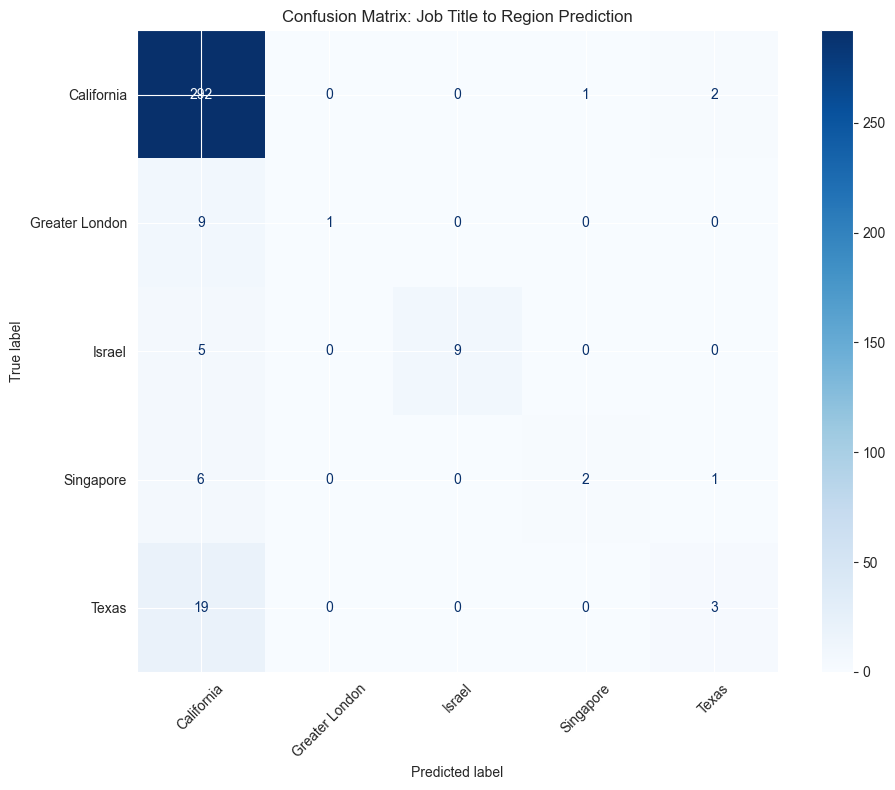

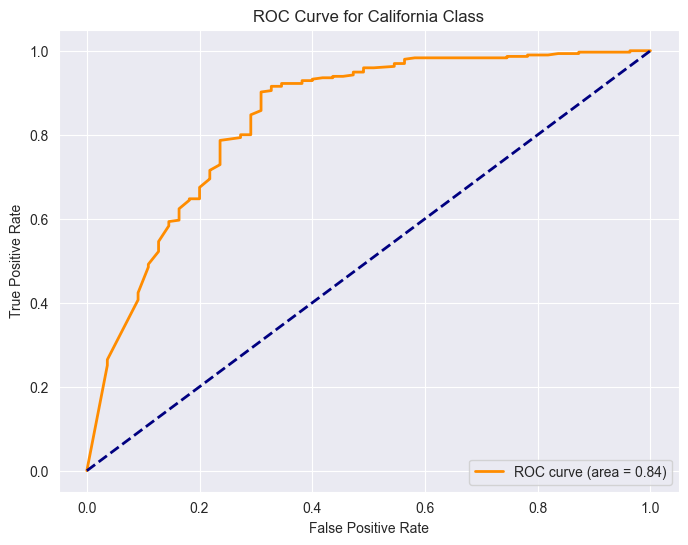

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score

df = pd.read_csv('C:\\Users\\ARUN\\Downloads\\apple_jobs_cleaned.csv')

top_regions = df['state_region'].value_counts().nlargest(5).index
df_filtered = df[df['state_region'].isin(top_regions)].copy()

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X = tfidf.fit_transform(df_filtered['title'])

le = LabelEncoder()
y = le.fit_transform(df_filtered['state_region'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Job Title to Region Prediction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ca_idx = np.where(le.classes_ == 'California')[0][0]

fpr, tpr, _ = roc_curve(y_test == ca_idx, y_probs[:, ca_idx])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for California Class')
plt.legend(loc="lower right")
plt.show()